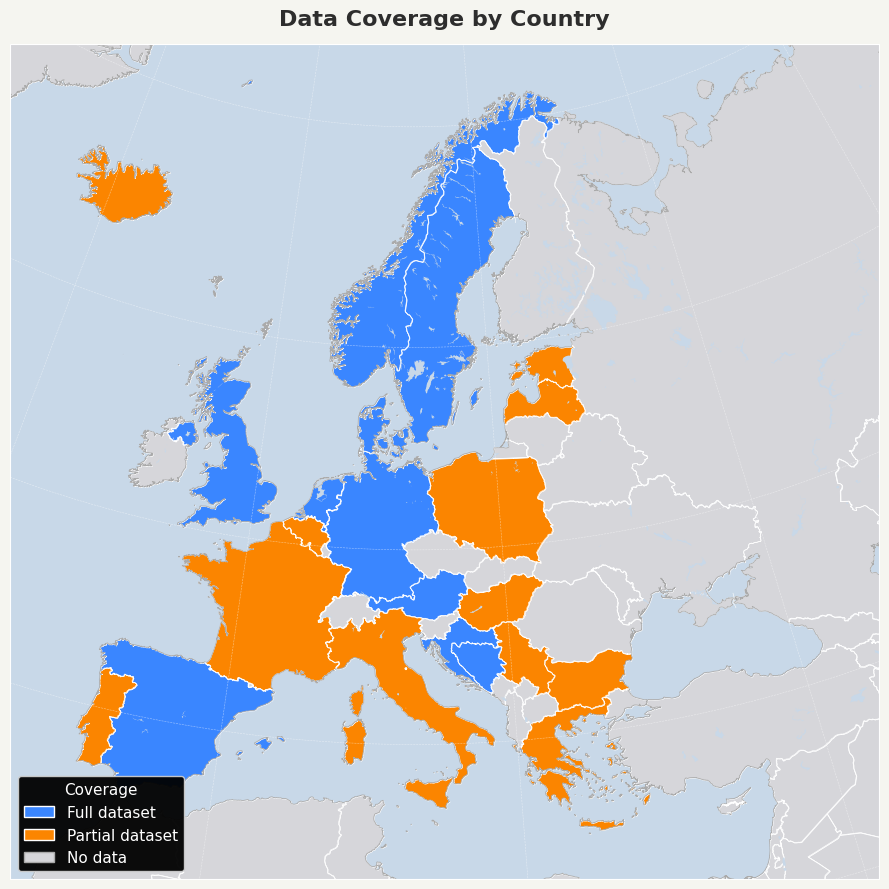

In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Your country lists ---
full_dataset_countries = {
    "Germany", "Austria", "Bosnia and Herzegovina", "Czechia",
    "Denmark", "Spain", "Netherlands", "United Kingdom", "Norway", "Croatia", "Sweden"
}
partial_dataset_countries = {
    "Belgium", "Estonia", "Greece", "Hungary",
    "Iceland", "Italy", "Poland", "France", "Serbia", "Portugal", "Bulgaria", "Latvia"
}

color_map = {
    "full":    "#3A86FF",
    "partial": "#FB8500",
    "none":    "#D6D6DA",
}

# --- Load Natural Earth country shapes via Cartopy ---
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = list(reader.records())

# --- Set up figure with Lambert Conformal projection (standard for Europe) ---
proj = ccrs.LambertConformal(central_longitude=13, central_latitude=52)

fig, ax = plt.subplots(
    figsize=(11, 9),
    subplot_kw=dict(projection=proj),
    facecolor="#F5F5F0"
)
ax.set_facecolor("#C8D8E8")  # ocean
ax.set_extent([-12, 42, 33, 72], crs=ccrs.PlateCarree())

# --- Draw countries ---
for country in countries:
    name = country.attributes["NAME_LONG"]
    if name in full_dataset_countries:
        color = color_map["full"]
    elif name in partial_dataset_countries:
        color = color_map["partial"]
    else:
        color = color_map["none"]

    ax.add_geometries(
        [country.geometry],
        ccrs.PlateCarree(),
        facecolor=color,
        edgecolor="white",
        linewidth=0.6,
    )

# --- Add coastlines and borders for polish ---
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6, color="#aaaaaa")
ax.add_feature(cfeature.BORDERS.with_scale('10m'),   linewidth=0.4, color="white")
ax.add_feature(cfeature.OCEAN.with_scale('10m'),     facecolor="#C8D8E8")
ax.add_feature(cfeature.LAKES.with_scale('10m'),     facecolor="#C8D8E8", linewidth=0)

# --- Subtle gridlines ---
gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=False,
    linewidth=0.4, color="white", alpha=0.5, linestyle="--"
)

# --- Legend ---
legend_handles = [
    mpatches.Patch(facecolor=color_map["full"],    edgecolor="white", label="Full dataset"),
    mpatches.Patch(facecolor=color_map["partial"], edgecolor="white", label="Partial dataset"),
    mpatches.Patch(facecolor=color_map["none"],    edgecolor="#aaaaaa", label="No data"),
]
ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.95,
    edgecolor="#cccccc",
    fontsize=11,
    title="Coverage",
    title_fontsize=11,
)

ax.set_title("Data Coverage by Country", fontsize=16, fontweight="bold", pad=14, color="#2D2D2D")

plt.tight_layout()
plt.savefig("europe_map_cartopy.png", dpi=200, bbox_inches="tight")
plt.show()